# Russian-to-English Neural Machine Translation

### Building sequence-to-sequence translation models from scratch with GRU networks, subword tokenization, and attention

`Python` · `PyTorch` · `NLP` · `Seq2Seq` · `Attention` · `BLEU`

## Project overview

This project develops a Russian-to-English neural machine translation pipeline for hotel descriptions. It begins with subword preprocessing, implements a recurrent encoder–decoder architecture from first principles, and then extends the baseline with an additive attention mechanism.

The central objective is to study how architectural choices affect translation quality while keeping the full data, training, inference, and evaluation workflow transparent.

## Text representation with Byte Pair Encoding

Machine translation requires a practical compromise between word-level and character-level tokenization. A word-level vocabulary can become extremely large when a corpus contains rare property names, locations, amenities, and descriptive terms. Character-level sequences avoid out-of-vocabulary words but are considerably longer and more difficult to model.

[Byte Pair Encoding (BPE)](https://github.com/rsennrich/subword-nmt) provides a middle ground. It begins with individual characters and repeatedly merges frequent adjacent symbols, producing reusable subword units. Frequent words can remain intact, while uncommon words are decomposed into smaller pieces that the model already knows.

### Preprocessing strategy

The pipeline uses `WordPunctTokenizer` for lowercasing and initial tokenization, followed by the `subword-nmt` implementation of BPE. Separate English and Russian merge rules are learned with 8,000 symbols per language.

This representation reduces vocabulary sparsity while preserving the ability to construct rare words and names from known subword units.

In [1]:
!pip install subword_nmt

In [2]:
from nltk.tokenize import WordPunctTokenizer
from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE


tokenizer = WordPunctTokenizer()
def tokenize(x):
    return ' '.join(tokenizer.tokenize(x.lower()))

# Tokenize the parallel corpus and write each language to a separate file
with open('train.en', 'w',encoding="utf8") as f_src,  open('train.ru', 'w',encoding="utf8") as f_dst:
    for line in open('/content/data.txt',encoding='utf8'):
        src_line, dst_line = line.strip().split('\t')
        f_src.write(tokenize(src_line) + '\n')
        f_dst.write(tokenize(dst_line) + '\n')

# Learn language-specific BPE rules and apply subword encoding
bpe = {}
for lang in ['en', 'ru']:
    learn_bpe(open('./train.' + lang,encoding="utf8"), open('bpe_rules.' + lang, 'w',encoding="utf8"), num_symbols=8000)
    bpe[lang] = BPE(open('./bpe_rules.' + lang,encoding="utf8"))

    with open('train.bpe.' + lang, 'w',encoding="utf8") as f_out:
        for line in open('train.' + lang,encoding="utf8"):
            f_out.write(bpe[lang].process_line(line.strip()) + '\n')

100%|██████████| 8000/8000 [00:09<00:00, 829.96it/s]


### Vocabulary construction and data split

After BPE is fitted and applied, token-to-index vocabularies are created for the source and target languages. The parallel corpus is then separated into training and development partitions using a fixed random seed for reproducibility.

Special beginning-of-sequence (BOS), end-of-sequence (EOS), and padding symbols support batched recurrent processing and autoregressive decoding.

In [3]:
import numpy as np

In [4]:
data_inp = np.array(open('./train.bpe.ru').read().split('\n'))
data_out = np.array(open('./train.bpe.en').read().split('\n'))

from sklearn.model_selection import train_test_split
train_inp, dev_inp, train_out, dev_out = train_test_split(data_inp, data_out, test_size=3000,
                                                          random_state=42)
for i in range(3):
    print('inp:', train_inp[i])
    print('out:', train_out[i], end='\n\n')

inp: на территории обустроена бесплатная частная парковка .
out: free private parking is available on site .

inp: кроме того , в 5 минутах ходьбы работают многочисленные бары и рестораны .
out: guests can find many bars and restaurants within a 5 - minute walk .

inp: отель san mi@@ gu@@ el расположен в центре мор@@ ели@@ и , в 750 метрах от главной площади города и кафедрального собора .
out: hotel san miguel is located in central more@@ lia , 750 metres from the city ’ s main square and cathedral .



In [5]:
from vocab import Vocab
inp_voc = Vocab.from_lines(train_inp)
out_voc = Vocab.from_lines(train_out)

In [6]:
# Demonstrate reversible mapping between tokens and vocabulary indices
batch_lines = sorted(train_inp, key=len)[5:10]
batch_ids = inp_voc.to_matrix(batch_lines)
batch_lines_restored = inp_voc.to_lines(batch_ids)

print("lines")
print(batch_lines)
print("\nwords to ids (0 = bos, 1 = eos):")
print(batch_ids)
print("\nback to words")
print(batch_lines_restored)

lines
[np.str_('гостевой дом r .'), np.str_('до афин — 20 км .'), np.str_('работает боулинг .'), np.str_('оборудован балкон .'), np.str_('подключен wi - fi .')]

words to ids (0 = bos, 1 = eos):
tensor([[   0, 2688, 2943, 1108,   29,    1,    1,    1],
        [   0, 2922, 1834, 8035,   59, 3800,   29,    1],
        [   0, 6030, 2083,   29,    1,    1,    1,    1],
        [   0, 4927, 1870,   29,    1,    1,    1,    1],
        [   0, 5549, 1453,   27,  592,   29,    1,    1]])

back to words
['гостевой дом r .', 'до афин — 20 км .', 'работает боулинг .', 'оборудован балкон .', 'подключен wi - fi .']


## Model development

The modeling stage progresses from a transparent recurrent baseline to an attention-enhanced architecture. Implementing both components directly in PyTorch makes it possible to inspect the hidden-state flow, decoding logic, loss masking, and inference procedure.

### Baseline GRU encoder–decoder

The baseline model consists of:

- source- and target-language embedding layers;
- a GRU encoder that transforms the Russian input sequence into hidden representations;
- a learned projection that initializes the decoder state;
- a `GRUCell` decoder that predicts one English token at a time;
- greedy autoregressive inference beginning with the BOS token.

Teacher forcing is used during training by supplying the reference target prefix to the decoder.

In [ ]:
#https://habr.com/ru/articles/567610/
#https://betterprogramming.pub/a-guide-on-the-encoder-decoder-model-and-the-attention-mechanism-401c836e2cdb
#https://cjlise.github.io/machine-learning/Neural-Machine-Translation-Attention/
#https://medium.com/nlplanet/a-full-guide-to-finetuning-t5-for-text2text-and-building-a-demo-with-streamlit-c72009631887
#https://github.com/artemxx/NMT/blob/main/main.ipynb

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [9]:
class BaseModel(nn.Module):
    def __init__(self, inp_voc, out_voc, emb_size=64, hid_size=128):
        """
        Baseline encoder-decoder architecture.
        """
        super().__init__()

        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        self.emb_inp = nn.Embedding(len(inp_voc), emb_size)
        self.emb_out = nn.Embedding(len(out_voc), emb_size)
        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True)

        self.dec_start = nn.Linear(hid_size, hid_size)
        self.dec0 = nn.GRUCell(emb_size, hid_size)
        self.logits = nn.Linear(hid_size, len(out_voc))

    def forward(self, inp, out):
        """Encode the source sequence and decode the target sequence."""
        initial_state = self.encode(inp)
        return self.decode(initial_state, out)


    def encode(self, inp, **flags):
        """
        Compute the hidden state used to initialize the decoder.
        :param inp: matrix of input token indices
        :returns: hidden representation used to initialize decoding
        """
        inp_emb = self.emb_inp(inp)
        batch_size = inp.shape[0]
        enc_seq, [last_state_but_not_really] = self.enc0(inp_emb)
        # enc_seq: [batch, time, hid_size], last_state: [batch, hid_size]

        # Padding makes the last tensor position unreliable; compute each true sequence length
        # and select the corresponding final encoder state.
        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        # ^-- shape: [batch_size, hid_size]

        dec_start = self.dec_start(last_state)
        return [dec_start]

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Use the previous decoder state and token to compute the next state and token logits.
        """
        prev_gru0_state = prev_state[0]
        out_emb = self.emb_out(prev_tokens)
        new_dec_state = self.dec0(out_emb, prev_gru0_state)
        output_logits = self.logits(new_dec_state)
        return [new_dec_state], output_logits

    def decode(self, initial_state, out_tokens, **flags):
        batch_size = out_tokens.shape[0]
        state = initial_state

        # Every decoded sequence begins with BOS
        onehot_bos = F.one_hot(torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64),
                               num_classes=len(self.out_voc)).to(device=out_tokens.device)
        first_logits = torch.log(onehot_bos.to(torch.float32) + 1e-9)

        logits_sequence = [first_logits]
        # Apply one decoding step per target position
        for i in range(out_tokens.shape[1] - 1):
            state, logits = self.decode_step(state, out_tokens[:, i])
            logits_sequence.append(logits)
        return torch.stack(logits_sequence, dim=1)

    def decode_inference(self, initial_state, max_len=100, **flags):
        """Generate target tokens autoregressively."""
        batch_size, device = len(initial_state[0]), initial_state[0].device
        state = initial_state
        outputs = [torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64, device=device)]
        all_states = [initial_state]

        for i in range(max_len):
            state, logits = self.decode_step(state, outputs[-1])
            outputs.append(logits.argmax(dim=-1))
            all_states.append(state)

        return torch.stack(outputs, dim=1), all_states

    def translate_lines(self, inp_lines, **kwargs):
        """Translate a collection of source-language strings."""
        inp = self.inp_voc.to_matrix(inp_lines).to(device)
        initial_state = self.encode(inp)
        out_ids, states = self.decode_inference(initial_state, **kwargs)
        return self.out_voc.to_lines(out_ids.cpu().numpy()), states


In [10]:
# debugging area
model = BaseModel(inp_voc, out_voc).to(device)

dummy_inp_tokens = inp_voc.to_matrix(sorted(train_inp, key=len)[5:10]).to(device)
dummy_out_tokens = out_voc.to_matrix(sorted(train_out, key=len)[5:10]).to(device)

h0 = model.encode(dummy_inp_tokens)
h1, logits1 = model.decode_step(h0, torch.arange(len(dummy_inp_tokens), device=device))

assert isinstance(h1, list) and len(h1) == len(h0)
assert h1[0].shape == h0[0].shape and not torch.allclose(h1[0], h0[0])
assert logits1.shape == (len(dummy_inp_tokens), len(out_voc))

logits_seq = model.decode(h0, dummy_out_tokens)
assert logits_seq.shape == (dummy_out_tokens.shape[0], dummy_out_tokens.shape[1], len(out_voc))

# full forward
logits_seq2 = model(dummy_inp_tokens, dummy_out_tokens)
assert logits_seq2.shape == logits_seq.shape

In [11]:
dummy_translations, dummy_states = model.translate_lines(train_inp[:3], max_len=25)
print(train_inp[:3])
print("Translations without training:")
print('\n'.join([line for line in dummy_translations]))

['на территории обустроена бесплатная частная парковка .'
 'кроме того , в 5 минутах ходьбы работают многочисленные бары и рестораны .'
 'отель san mi@@ gu@@ el расположен в центре мор@@ ели@@ и , в 750 метрах от главной площади города и кафедрального собора .']
Translations without training:
siesta könig@@ chamo@@ н@@ ven oceanfront bike roma inform@@ sit@@ babysitting green@@ used cun@@ note mal@@ connecting connecting hectare lucia rafael rafael corporate corporate brze@@
siesta könig@@ chamo@@ н@@ ven oceanfront bike roma inform@@ sit@@ babysitting green@@ used cun@@ note mal@@ connecting connecting hectare lucia rafael rafael corporate corporate brze@@
siesta könig@@ chamo@@ н@@ ven oceanfront bike roma inform@@ sit@@ babysitting green@@ used cun@@ note mal@@ connecting connecting hectare lucia rafael rafael corporate corporate brze@@


### Masked sequence loss

The model is optimized with token-level negative log-likelihood:

$$L = \frac{1}{|D|} \sum_{X,Y\in D} \sum_{y_t\in Y} -\log p(y_t \mid y_1,\ldots,y_{t-1},X,\theta)$$

The target mask includes the first EOS token and excludes subsequent padding positions. Loss is normalized by the number of valid target tokens so that batches containing different sentence lengths remain comparable.

In [12]:
def loss_function(model, inp, out, **flags):
    """
    Compute masked token-level negative log-likelihood.
    :param inp: input tokens matrix, int32[batch, time]
    :param out: reference tokens matrix, int32[batch, time]

    The mask includes the first EOS token, excludes subsequent padding,
    and normalizes loss by the number of valid target positions.
    """
    mask = model.out_voc.compute_mask(out) # [batch_size, out_len]
    targets_1hot = F.one_hot(out, len(model.out_voc)).to(torch.float32)

    # outputs of the model, [batch_size, out_len, num_tokens]
    logits_seq = model(inp, out)
    # Log-probabilities for every token at every decoding step
    logprobs_seq = F.log_softmax(logits_seq, dim=-1) # [batch_size, out_len, num_tokens]

    # Select log-probabilities assigned to reference tokens
    logp_out =  (logprobs_seq * targets_1hot).sum(dim=-1)# [batch_size, out_len]
    # The computation is fully vectorized across batch and time

    # Average cross-entropy over valid target tokens
    return  (-(logp_out * mask).sum(dim=-1) / mask.sum(dim=-1)).mean()# scalar loss

In [13]:
dummy_loss = loss_function(model, dummy_inp_tokens, dummy_out_tokens)
print("Loss:", dummy_loss)
assert np.allclose(dummy_loss.item(), 7.5, rtol=0.1, atol=0.1)

# test autograd
dummy_loss.backward()
for name, param in model.named_parameters():
    assert param.grad is not None and abs(param.grad.max()) != 0, f"Param {name} received no gradients"

Loss: tensor(7.5073, device='cuda:0', grad_fn=<MeanBackward0>)


### Evaluation metric: BLEU

Translation quality is evaluated with corpus-level [BLEU](https://en.wikipedia.org/wiki/BLEU). The metric measures modified n-gram precision for n-grams of lengths one through four and combines them using a geometric mean.

BPE continuation markers are removed before evaluation so that predictions and references are scored as normal text.

In [14]:
from nltk.translate.bleu_score import corpus_bleu
def compute_bleu(model, inp_lines, out_lines, bpe_sep='@@ ', **flags):
    """
    Compute corpus BLEU after merging BPE continuation tokens.
    """
    with torch.no_grad():
        translations, _ = model.translate_lines(inp_lines, **flags)
        translations = [line.replace(bpe_sep, '') for line in translations]
        actual = [line.replace(bpe_sep, '') for line in out_lines]
        return corpus_bleu(
            [[ref.split()] for ref in actual],
            [trans.split() for trans in translations],
            smoothing_function=lambda precisions, **kw: [p + 1.0 / p.denominator for p in precisions]
            ) * 100

In [15]:
compute_bleu(model, dev_inp, dev_out)

0.0018613554464099087

### Baseline training

The baseline is optimized with Adam on randomly sampled mini-batches. Training loss and development BLEU are recorded throughout training, and the notebook preserves the learning curves and representative translations for qualitative inspection.

In [16]:
from IPython.display import clear_output
from tqdm import tqdm, trange
from matplotlib import pyplot as plt
metrics = {'train_loss': [], 'dev_bleu': [] }

model = BaseModel(inp_voc, out_voc).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
batch_size = 32

num_iter = 25000


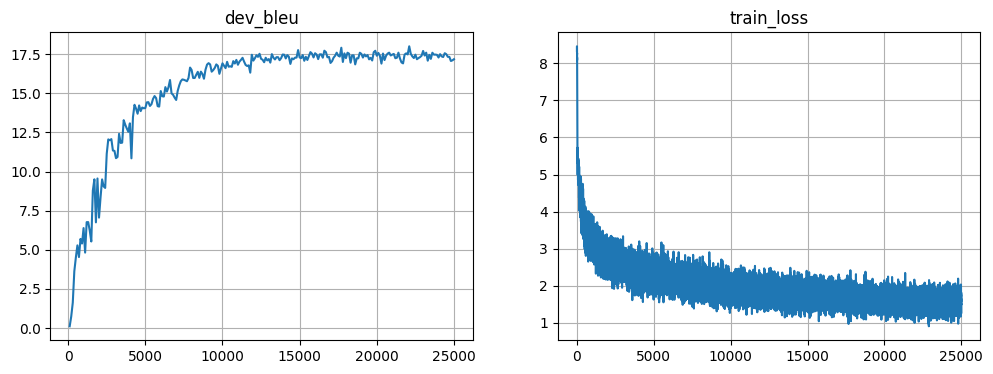

Mean loss=1.484


100%|██████████| 25000/25000 [18:53<00:00, 22.06it/s]


In [17]:
for i in trange(num_iter):
    #step = len(metrics['train_loss']) + 1

    batch_ix = np.random.randint(len(train_inp), size=batch_size)
    batch_inp = inp_voc.to_matrix(train_inp[batch_ix]).to(device)
    batch_out = out_voc.to_matrix(train_out[batch_ix]).to(device)

    opt.zero_grad()

    loss = loss_function(model, batch_inp, batch_out)

    loss.backward()

    opt.step()

    metrics['train_loss'].append((i + 1, loss.item()))

    if (i + 1) % 100 == 0:
        metrics['dev_bleu'].append((i + 1, compute_bleu(model, dev_inp, dev_out)))

        clear_output(True)
        plt.figure(figsize=(12,4))
        for j, (name, history) in enumerate(sorted(metrics.items())):
            plt.subplot(1, len(metrics), j + 1)
            plt.title(name)
            plt.plot(*zip(*history))
            plt.grid()
        plt.show()
        print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)


In [18]:
assert np.mean(metrics['dev_bleu'][-10:], axis=0)[1] > 15, "Not a bad result, but you can better"

In [19]:
for inp_line, trans_line in zip(dev_inp[::500], model.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

в распоряжении гостей общая кухня и общая гостиная .
shared kitchen facilities are also available .

кроме того , предоставляется прокат велосипедов , услуги трансфера и бесплатная парковка .
a tour desk , free parking and shuttle services are available .

расстояние до города ки@@ сси@@ м@@ ми составляет 26 км .
dav@@ ras m is 26 km away .

апартаменты в пент@@ хаусе с общим открытым бассейном , садом , кондиционером и террасой для загара расположены в 5 минутах ходьбы от пляжа на курорте ка@@ бо - рой .
located in the centre of 5 , this apartment features a garden with a terrace and a garden with a terrace and a garden with a barbecue .

апартаменты mo@@ s@@ co@@ w point - loft red square находятся в москве , в 200 метрах от большого театра .
tor@@ len@@ a is located in budapest , 200 metres from the roman amphitheatre .

в вашем распоряжении собственная ванная комната с душем и полотенцами .
featuring a shower , private bathrooms also come with towels .



In [20]:
np.mean(metrics['dev_bleu'][-10:], axis=0)[1]

np.float64(17.330181063132247)

Not a bad result having BLEU equal to 17.3 but it's far from ideal. Therefore I will try to add attenchion mechanism.

## Adding an attention mechanism

A single fixed encoder state can become an information bottleneck for longer sequences. The second architecture allows the decoder to focus dynamically on different source positions at every generation step.

### Architecture extension

The baseline is extended in two stages: first, a reusable additive attention layer is implemented; second, it is integrated into the decoder. The attention context is concatenated with the target-token embedding before the recurrent update.

### Additive attention layer

Given encoder states $h^e_0,h^e_1,\ldots,h^e_T$ and the previous decoder state $h^d$, alignment logits are computed as:

$$a_t = linear_{out}(tanh(linear_e(h^e_t) + linear_d(h^d)))$$

The logits are converted into normalized attention probabilities:

$$p_t = \frac{e^{a_t}}{\sum_\tau e^{a_\tau}}$$

The context vector is the probability-weighted sum of encoder states:

$$attn = \sum_t p_t \cdot h^e_t$$

Padding positions are masked before softmax so they receive no attention mass.

In [21]:
class AttentionLayer(nn.Module):
    def __init__(self, name, enc_size, dec_size, hid_size, activ=torch.tanh):
        super().__init__()
        self.name = name
        self.enc_size = enc_size
        self.dec_size = dec_size
        self.hid_size = hid_size

        # Projections used by additive attention
        self.linear1 = nn.Linear(enc_size, hid_size)
        self.linear2 = nn.Linear(dec_size, hid_size)
        self.linear3 = nn.Linear(hid_size, 1)
        self.soft = nn.Softmax(dim=-1)
        self.activ = activ

    def forward(self, enc, dec, inp_mask):
        """
        Compute the attention context vector and alignment probabilities.
        :param enc: [batch_size, ninp, enc_size]
        :param dec: decode state[batch_size, dec_size]
        :param inp_mask: mask with zeros at padding positions [batch_size, ninp]
        :returns: attn[batch_size, enc_size], probs[batch_size, ninp]
        """

        # Compute alignment logits

        batch_size, n_inp, enc_size = enc.shape
        tmp = self.linear2(dec)
        tmp = tmp.reshape(-1, 1, self.hid_size)

        x = self.linear1(enc)
        x = self.activ(x + tmp)
        x = self.linear3(x)

        # Apply mask - if mask is 0, logits should be -inf or -1e9
        x[torch.where(inp_mask == False)] = -1e9

        # Compute attention probabilities (softmax)
        probs = self.soft(x.reshape(batch_size, n_inp))

        # Compute attention response using enc and probs
        attn = (probs.reshape(batch_size, n_inp, 1) * enc).sum(axis=1)

        assert tuple(attn.shape) == (batch_size, enc_size)
        assert tuple(probs.shape) == (batch_size, n_inp)

        return attn, probs


### Attention-based sequence-to-sequence model

At each decoding step, the model uses the previous decoder state to calculate an attention distribution over the complete encoder sequence. The resulting context vector is concatenated with the current target embedding and passed to the decoder GRU cell.

The decoder state also retains the encoder sequence, source mask, and attention probabilities, making the mechanism available during both teacher-forced training and autoregressive inference.

In [22]:
class AttentiveModel(BaseModel):
    def __init__(self, name, inp_voc, out_voc,
                 emb_size=256, hid_size=256, attn_size=256):
        """Sequence-to-sequence translator with additive attention."""
        #nn.Module.__init__(self)
        #self.inp_voc, self.out_voc = inp_voc, out_voc
        #self.hid_size = hid_size
        #self.name = name
        #self.emb_inp = nn.Embedding(len(inp_voc), emb_size)
        #self.emb_out = nn.Embedding(len(out_voc), emb_size)
        super().__init__(inp_voc, out_voc, emb_size, hid_size)

        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True)
        self.dec_start = nn.Linear(hid_size, hid_size)
        self.dec0 = nn.GRUCell(emb_size + hid_size , hid_size)
        self.attn = AttentionLayer("attnLayer", hid_size, hid_size, attn_size)

        #self.dec_start = nn.Linear(hid_size, hid_size)
        #self.dec0 = nn.GRUCell(emb_size, hid_size)
        self.logits = nn.Linear(hid_size, len(out_voc))
        #self.attn = AttentionLayer("attnLayer", len(inp_voc), len(out_voc), attn_size)

    def encode(self, inp, **flags):
        """
        Compute encoder states and metadata used during decoding.
        :param inp: matrix of input token indices
        """
        inp_emb = self.emb_inp(inp)

        enc_seq, last_state_but_not_really = self.enc0(inp_emb)

        [dec_start] = super().encode(inp, **flags)

        enc_mask = self.out_voc.compute_mask(inp)

        # apply attention layer from initial decoder hidden state
        first_attn = self.attn(enc_seq, dec_start, enc_mask)[1]

        return [dec_start, enc_seq, enc_mask, first_attn]

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Use the previous state and token to compute the next decoder state and logits.
        :param prev_state: tensors representing the previous decoder state
        :param prev_tokens: previous output tokens [batch_size]
        :return: next decoder state tensors and token logits [batch, n_tokens]
        """

        prev_gru0_state, enc_seq, enc_mask, _ = prev_state
        attn, attn_prob = self.attn(enc_seq, prev_gru0_state, enc_mask)

        x = self.emb_out(prev_tokens)
        assert len(x.shape) == 2 and len(attn.shape) == 2

        x = torch.cat([attn, x], dim=-1)
        x = self.dec0(x, prev_gru0_state)

        new_dec_state = [x, enc_seq, enc_mask, attn_prob]
        output_logits = self.logits(x)

        return new_dec_state, output_logits


### Training the attentive model

The larger attention-based model uses 256-dimensional embeddings and hidden states. It is trained with the same masked objective and evaluated with the same development split, enabling a direct comparison with the recurrent baseline.

In [23]:
model = AttentiveModel("AttentionModel", inp_voc, out_voc).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
batch_size = 32
num_iter = 10000
metrics = {'train_loss': [], 'dev_bleu': [] }

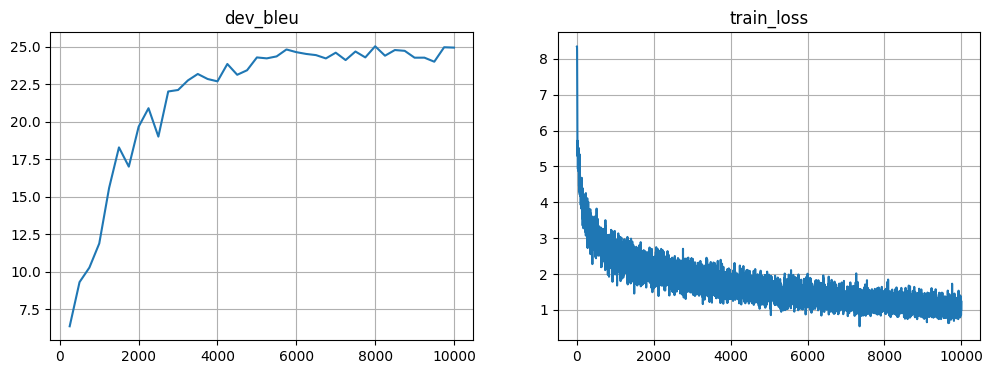

Mean loss=1.071


100%|██████████| 10000/10000 [20:27<00:00,  8.15it/s]


In [24]:
for i in trange(num_iter):
    #step = len(metrics['train_loss']) + 1
    batch_ix = np.random.randint(len(train_inp), size=batch_size)
    batch_inp = torch.tensor(inp_voc.to_matrix(train_inp[batch_ix])).to(device)
    batch_out = torch.tensor(out_voc.to_matrix(train_out[batch_ix])).to(device)
    opt.zero_grad()
    loss = loss_function(model, batch_inp, batch_out)
    loss.backward()
    opt.step()

    metrics['train_loss'].append((i + 1, loss.cpu().detach().numpy()))

    if (i + 1) % 250 == 0:
        metrics['dev_bleu'].append((i + 1, compute_bleu(model, dev_inp, dev_out)))

        clear_output(True)
        plt.figure(figsize=(12,4))
        for j, (name, history) in enumerate(sorted(metrics.items())):
            plt.subplot(1, len(metrics), j + 1)
            plt.title(name)
            plt.plot(*zip(*history))
            plt.grid()
        plt.show()
        print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)


In [25]:
compute_bleu(model, dev_inp, dev_out)

24.94660913544563

24.95 is quite a good BLEU score when the general gis is understandable, but styll contains major grammatical errors, especially when faces Proper Nouns.

In [26]:
assert np.mean(metrics['dev_bleu'][-10:], axis=0)[1] > 23, "Great result but still may be improved)"

In [27]:
for inp_line, trans_line in zip(dev_inp[::500], model.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

в распоряжении гостей общая кухня и общая гостиная .
shared kitchen is available and a shared lounge are offered .

кроме того , предоставляется прокат велосипедов , услуги трансфера и бесплатная парковка .
the property also offers bike hire , shuttle service and free parking .

расстояние до города ки@@ сси@@ м@@ ми составляет 26 км .
ka@@ unas is 26 km away .

апартаменты в пент@@ хаусе с общим открытым бассейном , садом , кондиционером и террасой для загара расположены в 5 минутах ходьбы от пляжа на курорте ка@@ бо - рой .
set in a 5 - minute walk from the beach , this apartment features a shared outdoor pool , terrace and a sun terrace .

апартаменты mo@@ s@@ co@@ w point - loft red square находятся в москве , в 200 метрах от большого театра .
apartamenty ali studio is set in a historic building , 200 metres from the theatre .

в вашем распоряжении собственная ванная комната с душем и полотенцами .
featuring a shower , private bathrooms also come with towels .



## Conclusions

This project demonstrates the complete construction of a neural machine translation system—from subword preprocessing and vocabulary management to recurrent encoding, autoregressive decoding, masked training, attention, and BLEU evaluation.

The attention-enhanced model which built from scratch achieved a saved development BLEU score of **25.0**, while the qualitative examples show generally fluent hotel-description phrasing with remaining errors in named entities and location-specific details. These results illustrate both the value of attention and the limitations of compact recurrent translation systems.

Potential extensions include beam-search decoding, bidirectional encoding, attention visualization, pretrained multilingual transformers, and systematic error analysis by sentence length and rare-token frequency.